# Shrinking body size and rising prey scarcity in Atlantic Forest birds

over three decades of climate change

Eduardo S.A. Santos [](https://orcid.org/0000-0002-0434-3655) (Collaboration for Open Science and Synthesis in Ecology and Evolution, Department of Biological Sciences, University of Alberta, Edmonton, AB, T6G 2E9, Canada)  
João C.T. Menezes [](https://orcid.org/0000-0003-4156-2934) (Organismic and Evolutionary Biology Graduate Program, University of Massachusetts Amherst, Amherst, MA, 01003, USA)  
Gustavo Burin [](https://orcid.org/0000-0001-7851-0666) (Department of Biological and Environmental Sciences, University of Gothenburg, Sweden)  
June 12, 2026

Declining body size has been proposed as a third universal response of animals to climate warming, alongside shifts in phenology and geographic range. Whether this response is widespread in the species-rich avifaunas of the tropics, and whether it tracks temperature directly or the availability of food, remains poorly resolved. Here we use the ATLANTIC BIRD TRAITS dataset to assemble morphological measurements for passerine bird species sampled across the Brazilian Atlantic Forest between 1990 and 2018, and analyse temporal trends in wing length and bill width with Bayesian phylogenetic multilevel models that account for sex, latitude, repeated sampling of species, and phylogenetic non-independence. Across species, wing length declined over the 28-year period — a decline robust to phylogenetic uncertainty and to the choice of phylogeny — whereas bill width, if anything, increased slightly and showed no comparable decline. The among-individual variability of wing length increased in the most recently sampled birds, consistent with a population responding heterogeneously to a changing environment. Over the same region and period, the abundance of arthropod prey declined steeply in forested biomes; the decline strengthened when ants were included as prey — justified by documented opportunistic predation of flying ant reproductives by passerines — and remained substantial under the conservative ant-exclusion assumption. Our findings link a regional collapse in invertebrate prey to morphological change in their avian predators, and illustrate why distinguishing thermoregulatory from trophic drivers of body-size change requires datasets that capture both climate and resources.

In [ ]:
arth    <- readRDS("../Analysis/output/arthropod_estimates.rds")
diet    <- readRDS("../Analysis/output/diet_interaction_results.rds")
dat_sum <- readRDS("../Analysis/output/data_summary.rds")
desc    <- readRDS("../Analysis/output/descriptive_summary.rds")  # quartile, lnCVR, pooled model numbers
drm_a   <- readRDS("../Analysis/output/drmsem_results_arthro.rds")   # drmSEM: arthropod-coverage causal model
drm_f   <- readRDS("../Analysis/output/drmsem_results_noarthro.rds") # drmSEM: full-record temperature/variance model

# format a count with a thousands separator for inline use
.n <- function(x) format(x, big.mark = ",", trim = TRUE)
# format a signed estimate / CI bound to 2 dp with a true minus sign
.s <- function(x) sub("-", "−", sprintf("%.2f", x))

# drmSEM helpers: pull a path coefficient / p-value / simulate-based effect
.dpath <- function(res, from, to, comp = "mu")            # raw path coefficient (2 dp, signed)
  .s(res$paths_sdx$estimate[res$paths_sdx$from == from &
       res$paths_sdx$to == to & res$paths_sdx$component == comp])
.dp <- function(res, from, to, comp = "mu") {             # formatted p-value ("< 0.001" or "= 0.004")
  p <- res$paths_sdx$p.value[res$paths_sdx$from == from &
         res$paths_sdx$to == to & res$paths_sdx$component == comp]
  if (p < 0.001) "< 0.001" else sub("=", "=", sprintf("= %.3f", p))
}
.deff <- function(res, slot, quantity, col = "estimate") {# simulate-based effect (2 dp, signed)
  d <- as.data.frame(res$effects[[slot]]); .s(d[[col]][d$quantity == quantity])
}

# helper: pull one number from a pooled-results data frame by parameter name
.pe <- function(df, par, col) round(df[[col]][df$par == par], 2)

# diet interaction
int_A   <- diet$model_A_pooled
yr_A    <- .pe(int_A, "b_scaled_yr",              "estimate")
int_est <- .pe(int_A, "b_scaled_yr:diet_inv_std", "estimate")
int_lo  <- .pe(int_A, "b_scaled_yr:diet_inv_std", "lower")
int_hi  <- .pe(int_A, "b_scaled_yr:diet_inv_std", "upper")
slope_low  <- round(yr_A - int_est, 2)   # diet −1 SD
slope_high <- round(yr_A + int_est, 2)   # diet +1 SD

# sensitivity threshold results (Tier 1)
sens <- tryCatch(readRDS("../Analysis/output/sensitivity_thresholds_tier1.rds"),
                 error = function(e) NULL)
if (!is.null(sens)) {
  n_sens_total     <- nrow(sens)
  n_sens_sexfilter <- sum(sens$sex_filter)
  n_neg_sexfilter  <- sum(sens$sex_filter  & sens$b_yr_hi < 0)
  n_neg_nosex      <- sum(!sens$sex_filter & sens$b_yr_hi < 0)
}

Two of the most widely documented responses of organisms to climate warming are shifts in phenology and in geographic range ([Parmesan and Yohe 2003](#ref-parmesan_globally_2003)). A third response — a reduction in body size — is increasingly reported across taxa and has been proposed as a general consequence of warming ([Gardner et al. 2011](#ref-gardner_declining_2011); [Sheridan and Bickford 2011](#ref-sheridan_shrinking_2011); [Teplitsky and Millien 2014](#ref-teplitsky_climate_2014)). The expectation follows from Bergmann’s rule, the ecogeographical pattern whereby endotherms are smaller in warmer climates because a higher surface-area-to-volume ratio aids heat dissipation ([Bergmann 1847](#ref-bergmann1847); [Mayr 1956](#ref-mayr1956); [Ashton 2002](#ref-ashton2002a)). Body-size reductions under warming may arise through temperature-dependent thermoregulatory mechanisms or through temperature-independent declines in food availability that constrain growth ([Gardner et al. 2011](#ref-gardner_declining_2011); [Schmidt and Jensen 2005](#ref-schmidt_concomitant_2005); [Teplitsky et al. 2008](#ref-teplitsky_bergmanns_2008)). Disentangling these pathways requires data on both climate and resources, which are rarely available together, especially in the tropics. Here we show that, across 89 passerine species sampled in the Brazilian Atlantic Forest between 1990 and 2018, wing length declined over time — though modestly and heterogeneously among species — while bill width did not decline (increasing slightly, if at all), and the among-individual variability of wing length rose in recently sampled birds. Over the same region and interval, the abundance of arthropod prey fell steeply. These results connect a regional decline in invertebrate prey to morphological change in their avian predators and underscore that body-size responses to climate change need not reflect thermoregulation alone ([Ozgul et al. 2009](#ref-ozgul2009); [Weeks et al. 2020](#ref-weeks2020); [Ryding et al. 2024](#ref-ryding2024)).

# 1. Results and discussion

## 1.1 Three decades of avian morphology in the Atlantic Forest

We drew morphological measurements from the ATLANTIC BIRD TRAITS dataset ([Rodrigues et al. 2019](#ref-rodrigues_atlantic_2019)), in which passerines account for 83% of all records (60,066 of 72,483 entries). Restricting to adult passerines recorded between 1990 and 2018 yielded 40,183 measurements. We retained species with at least 30 records; after removing individuals of unknown sex, requiring a sampling span of at least 5 years per species, and keeping only records inside a 20-km buffer of the Atlantic Forest domain, our analytical sample comprised 89 passerine species and 15,332 records (<a href="#fig-map" class="quarto-xref">Figure 1</a>). We used wing length

<figure id="fig-map">
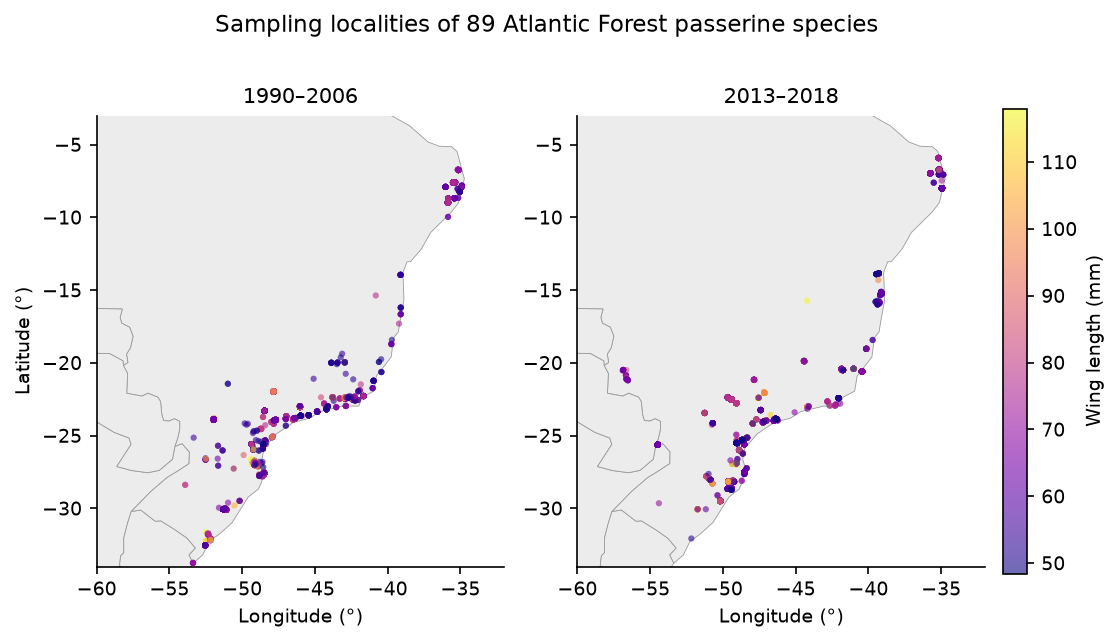
<figcaption>Figure 1: Sampling localities of the 89 passerine species across the Brazilian Atlantic Forest, shown separately for the early (1990–2006) and late (2013–2018) periods of the record, coloured by wing length.</figcaption>
</figure>

1.  as our index of body size because it had the fewest missing values among the available traits; assuming bilateral symmetry, we combined left, right, and unspecified wing measurements into a single variable to minimise missing data. Bill width (mm) provided a complementary trait expected to track diet rather than thermoregulation.

## 1.2 Wing length declined over time

We modelled wing length with Bayesian phylogenetic multilevel models including sex and latitude as fixed effects, a species-level random intercept structured by a phylogenetic covariance matrix derived from the complete avian phylogeny of McTavish et al. ([2025](#ref-mctavish2025tree)), and species-specific random intercepts and slopes for year; we propagated phylogenetic uncertainty across 50 trees and pooled estimates with Rubin’s rules (Methods). Using the coalesced wing-length variable, wing length decreased over time (standardized year effect β = −0.73, 95% CI −1.09 to −0.37, excluding zero), males were larger than females (β = 2.51 mm, 95% CI 2.30 to 2.71), and wing length declined with our latitude index (β = −0.40, 95% CI −0.59 to −0.22); the analysis used 9,861 wing-length records. Phylogeny accounted for the overwhelming majority of among-species variance (proportion = 0.96, 95% CI 0.94 to 0.96), as expected for a conserved morphological trait.

The temporal decline excluded zero and was robust to phylogenetic uncertainty and to the updated phylogeny (<a href="#fig-wingtrend" class="quarto-xref">Figure 2</a>). A complementary, model-free comparison of species means between the first (1990–2006) and last (2013–2018) quartiles of the record showed the same direction (<a href="#fig-trends" class="quarto-xref">Figure 3</a>): 53 of 77 species had smaller mean wing length in the later period, and 24 had larger.

<figure id="fig-wingtrend">
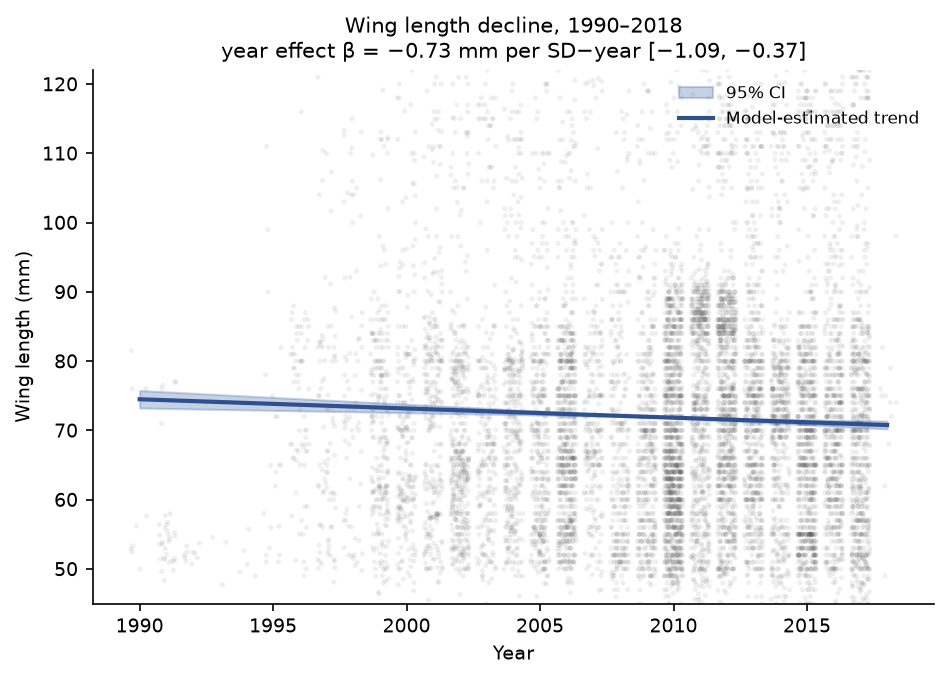
<figcaption>Figure 2: Wing length of 89 Atlantic Forest passerines against year of sampling, 1990–2018. Shading shows the density of individual records (log scale); the line is the model-estimated population trend with its 95% interval.</figcaption>
</figure>

<figure id="fig-trends">
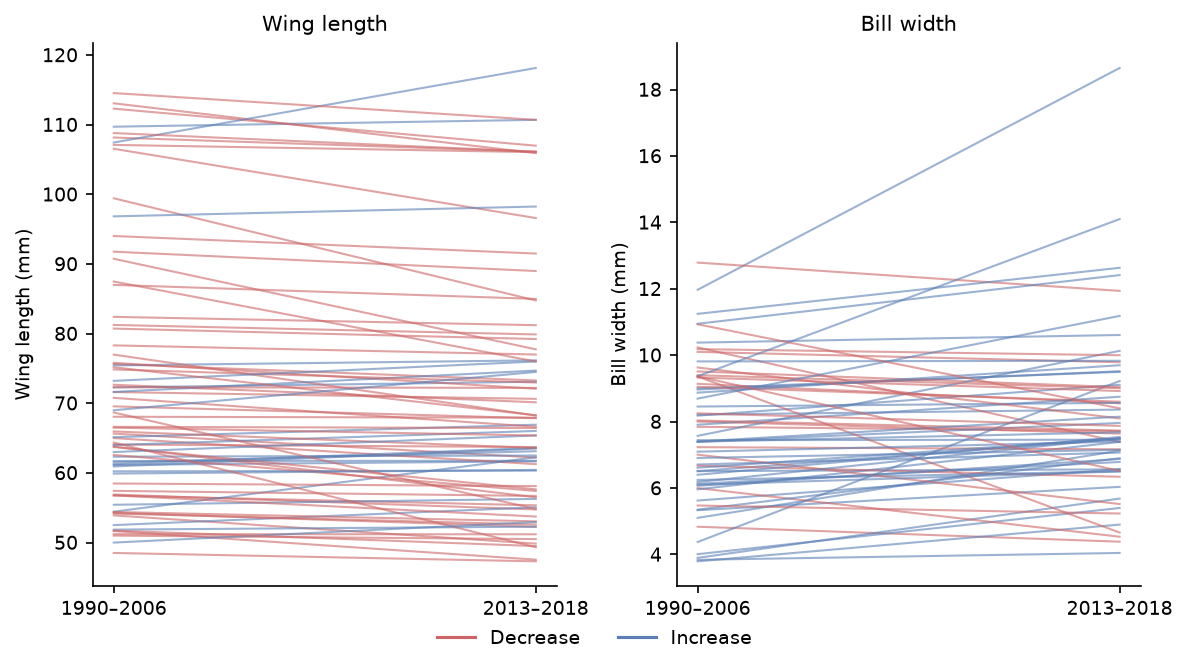
<figcaption>Figure 3: Temporal trends in (left) wing length and (right) bill width across species, 1990–2018. Lines show per-species trajectories; colour distinguishes species that decreased versus increased between the early and late periods.</figcaption>
</figure>

Although now statistically clear and robust to phylogenetic uncertainty, the decline remains modest in magnitude and, as we show next, is accompanied by rising among-individual variability. A body-size response that is real but small and increasingly variable is more compatible with a resource-mediated, plastic mechanism than with a uniform thermoregulatory adjustment.

## 1.3 Bill width did not decline, and trait variability rose

In contrast to the decline in wing length, bill width showed a slight *increase* over time (β = 0.17, 95% CI 0.03 to 0.32; N = 4,521 bill-width records), with a credible interval that only marginally excluded zero, and a weaker phylogenetic signal than wing length (proportion = 0.66, 95% CI 0.60 to 0.72); like wing length, it declined with our latitude index (β = −0.36, 95% CI −0.45 to −0.26). The quartile comparison agreed in direction, with most species (41 of 64) showing wider mean bills in the later period. Crucially, bill width — the trait expected to track diet rather than thermoregulation — moved in the opposite direction to wing length, rather than declining alongside it.

To ask whether birds became not just smaller but more variable, we computed the log coefficient-of-variation ratio (lnCVR) between the late and early periods for each species and combined them in random-effects meta-analyses ([Nakagawa et al. 2015](#ref-nakagawa2015metaanalysis)). Among-individual variability in wing length increased significantly in the recent period (lnCVR = 0.24, 95% CI 0.10 to 0.38; k = 70; I² = 94.1%; <a href="#fig-variability" class="quarto-xref">Figure 4</a>, left), whereas variability in bill width did not change detectably (lnCVR = −0.07, 95% CI −0.28 to 0.13; k = 54; <a href="#fig-variability" class="quarto-xref">Figure 4</a>, right). Rising phenotypic variability in the trait that also declined in mean is consistent with a population in which individuals respond unequally to a deteriorating environment, rather than with a coordinated shift toward a new optimum.

<figure id="fig-variability">
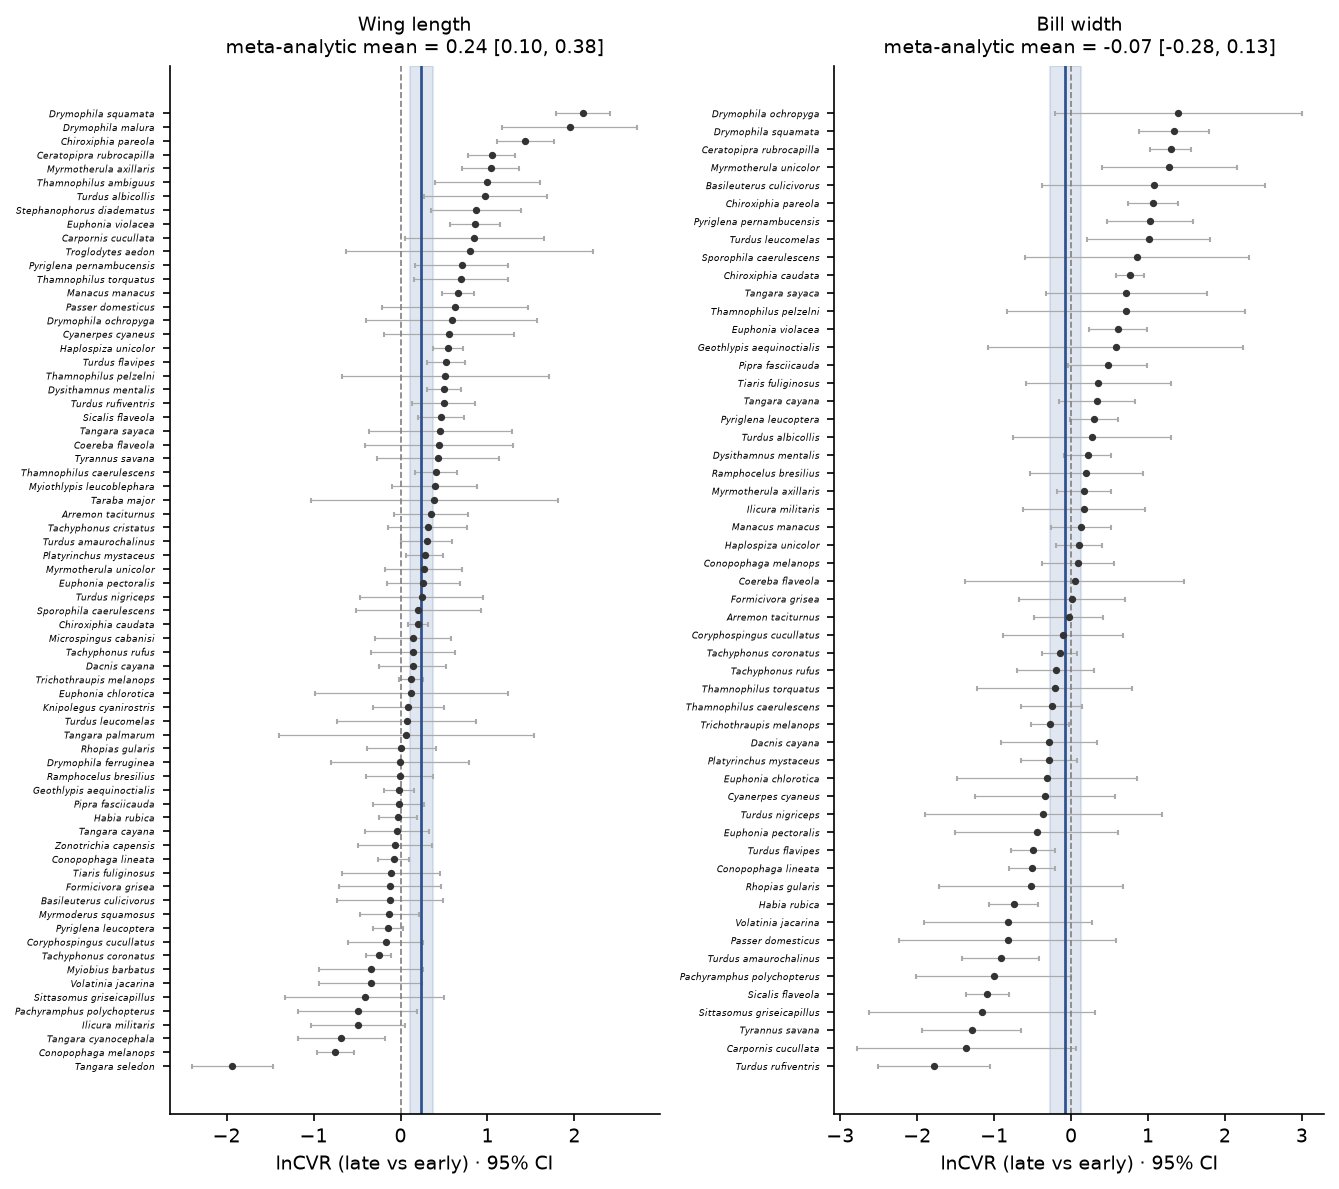
<figcaption>Figure 4: Forest plots of the log coefficient-of-variation ratio (lnCVR) between the late and early periods, for (left) wing length and (right) bill width, one estimate per species (95% CI), with the random-effects meta-analytic mean (vertical line, shaded 95% CI). Positive values indicate greater among-individual variability in recently sampled birds; intervals use the corrected standard errors.</figcaption>
</figure>

## 1.4 Arthropod prey declined steeply over the same region and period

If body-size change in these largely insectivorous birds is mediated by food rather than temperature, the abundance of their invertebrate prey should have declined over the study period. Using the PREDICTS database ([<span class="nocase">Hudson et al.</span> 2017](#ref-hudson2017database)), we modelled the abundance of Insecta and Arachnida in forested biomes across South America with negative-binomial models that included sampling effort as an offset (Methods). Although ants are not a core dietary component of most passerines, some species opportunistically predate flying ant reproductives (alates) during nuptial flights ([Helms et al. 2016](#ref-helms_are_2016)), so our main model retains Formicidae; the ant-exclusion variant serves as a conservative lower bound. Arthropod abundance declined markedly with time in the main model (standardized year effect β = -1.4, 95% CrI -1.46 to -1.34; N = 63150 records), equivalent to a multiplicative change of 0.25 (95% CrI 0.23 to 0.26) per standard-deviation increase in year (<a href="#fig-arthropods" class="quarto-xref">Figure 5</a>). Excluding ants gave a shallower but still substantial decline (β = -1.22, 95% CrI -1.29 to -1.15; N = 53139), confirming that including ants does not inflate the signal — if anything, their decline is steeper than the broader community. The arthropod prey collapse is therefore robust to the treatment of ants and restricted to forested habitats.

<figure id="fig-arthropods">
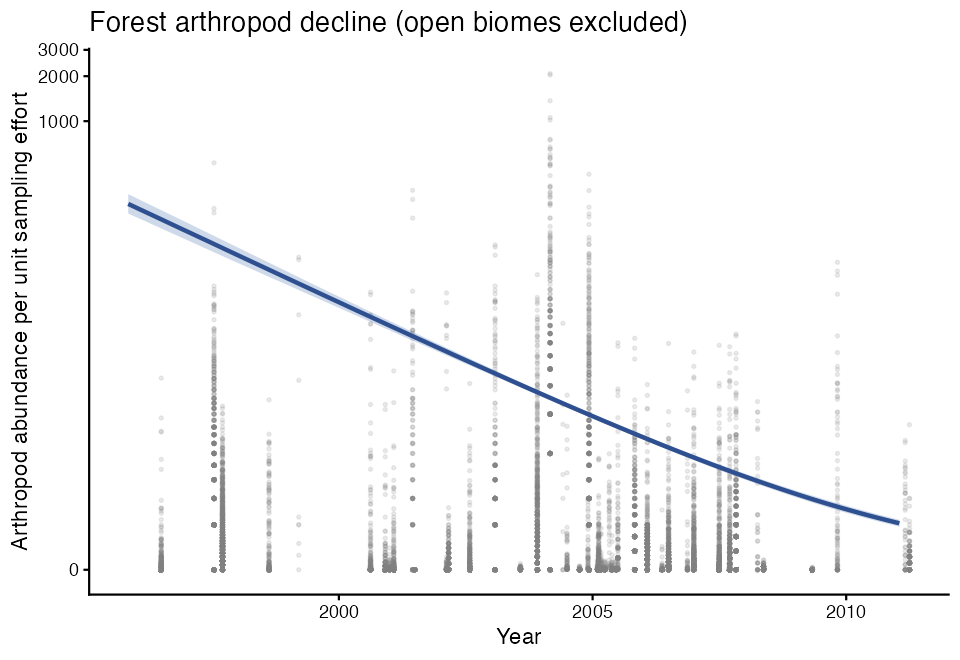
<figcaption>Figure 5: Abundance of Insecta and Arachnida in forested biomes across South America (PREDICTS database) against time, with the fitted negative-binomial trend and 95% credible interval. Ants (Formicidae) are included in the main model; the ant-exclusion sensitivity gave a shallower but qualitatively identical decline. <em>Placeholder pending regeneration from the analysis.</em></figcaption>
</figure>

## 1.5 The temporal decline is not amplified in more insectivorous species

If arthropod scarcity is the proximate driver of body-size change, species more reliant on invertebrate prey should show steeper temporal trends in wing length. We tested this by adding an interaction between scaled year and each species’ standardised proportion of invertebrates in their diet (Diet-Inv from EltonTraits ([Wilman et al. 2014](#ref-wilman2014eltontraits)); Methods). Of the 89 species in the main analysis, 76 had EltonTraits diet data and were retained; the 13 species without diet information were excluded from this model only.

The interaction was positive and its 95% credible interval excluded zero (β = 0.52, 95% CI 0.18 to 0.87), meaning that species with *less* invertebrate diet declined *more* steeply — the opposite of the food-limitation prediction. Projecting the year slope across the diet gradient, species one standard deviation below the mean in invertebrate diet proportion had an implied slope of -1.25 mm per SD-year, compared with -0.21 mm per SD-year for species one standard deviation above the mean (<a href="#fig-dietinteraction" class="quarto-xref">Figure 6</a>). The overall year effect remained negative and excluded zero (β = -0.73; consistent with the main analysis), confirming the decline is real across diet types; it is simply not concentrated in the most insectivorous species.

<figure id="fig-dietinteraction">
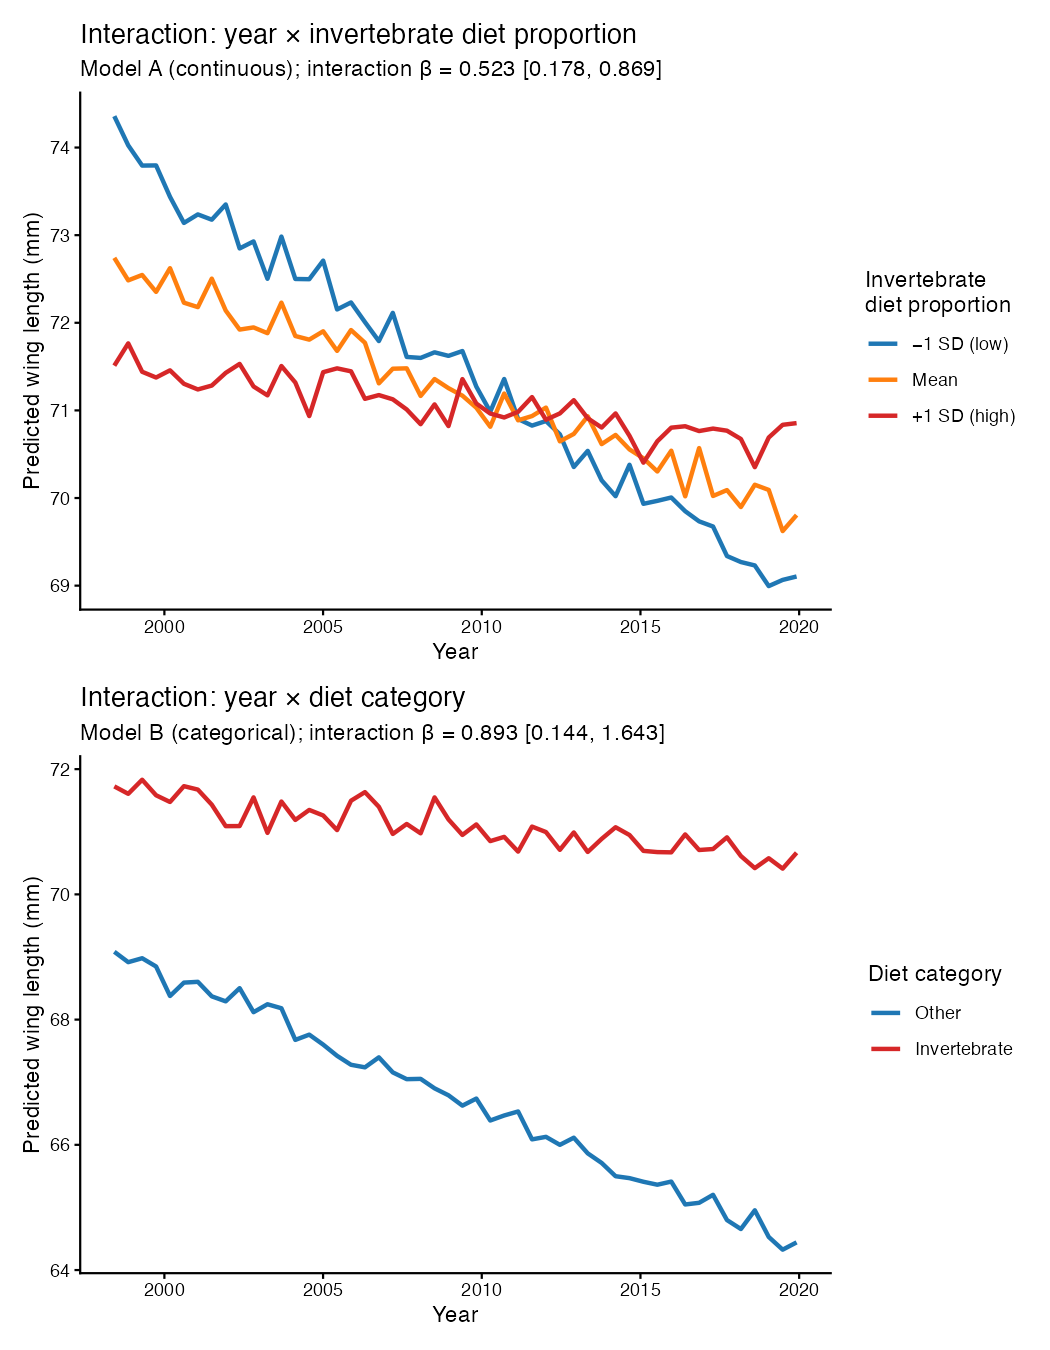
<figcaption>Figure 6: Predicted wing-length year trend as a function of invertebrate diet proportion (standardised), from the phylogenetic interaction model. Lines show the predicted trajectory for females at mean latitude; shading is the 95% credible interval. The positive interaction indicates that species with less invertebrate diet show the steeper temporal decline.</figcaption>
</figure>

## 1.6 A causal model separates the prey and temperature pathways

The diet interaction shows that the decline is not concentrated in the most insectivorous species, but it does not by itself adjudicate between the temperature and food-limitation pathways. We therefore fitted a distributional piecewise structural equation model \[drmSEM; Shipley ([2009](#ref-shipley2009confirmatory)); Lefcheck ([2016](#ref-lefcheck2016piecewisesem)); Nakagawa, Pottier, et al. ([2026](#ref-nakagawa2026drmsem))\] encoding the hypothesised causal graph: year and latitude drive temperature; year, temperature and latitude drive arthropod abundance; and temperature, arthropod abundance, sex and latitude drive wing length, with a distributional submodel letting the residual variance of wing length depend on year and temperature (Methods; <a href="#fig-drmsem" class="quarto-xref">Figure 7</a>).

On the years with arthropod coverage (1998–2008; N = 2,149 records, 82 species), the graph was consistent with the data (Fisher’s C = 7.7, df = 4, P = 0.1). Arthropod abundance fell steeply with year (path = −0.87, P \< 0.001), independently reproducing the prey collapse — yet arthropod abundance itself had no detectable direct association with wing length (path = +0.09, P = 0.468), and the year → wing route through prey was indistinguishable from zero (−0.03 mm, 95% CI −0.12 to 0.06). Temperature, by contrast, was directly associated with smaller wings within this window (path = −0.63, P = 0.004; total temperature effect −0.45 mm, 95% CI −0.74 to −0.19).

This direct temperature–size association was not, however, robust to the sampling window. On the full record (1990–2018; N = 9,180 records, 86 species), temperature’s direct association with the wing-length *mean* was not distinguishable from zero (path = +0.13, P = 0.246), so we do not read the model as firmly localising the *mean* decline to either measured mediator. What the full record did show, robustly, was a distributional signal: the residual variability of wing length increased with year (σ path = +0.07, P \< 0.001) and was lower in warmer years (σ path = −0.17, P \< 0.001), corroborating the lnCVR result under an explicit causal model. All path directions were unchanged when phylogenetic non-independence was propagated across 50 trees, and the primary brms models remain the formal authority.

The clearest message of the causal model is therefore negative but informative: the regional prey decline, though real and steep, is not the proximate driver of the morphological change — consistent with the diet-interaction null — while the rising among-individual variance of wing length is reproduced under an explicit graph. The temporal change in the *mean*, modest to begin with, is not cleanly attributable to per-record temperature either, leaving regional warming acting through pathways that our covariates capture only partially.

<figure id="fig-drmsem">
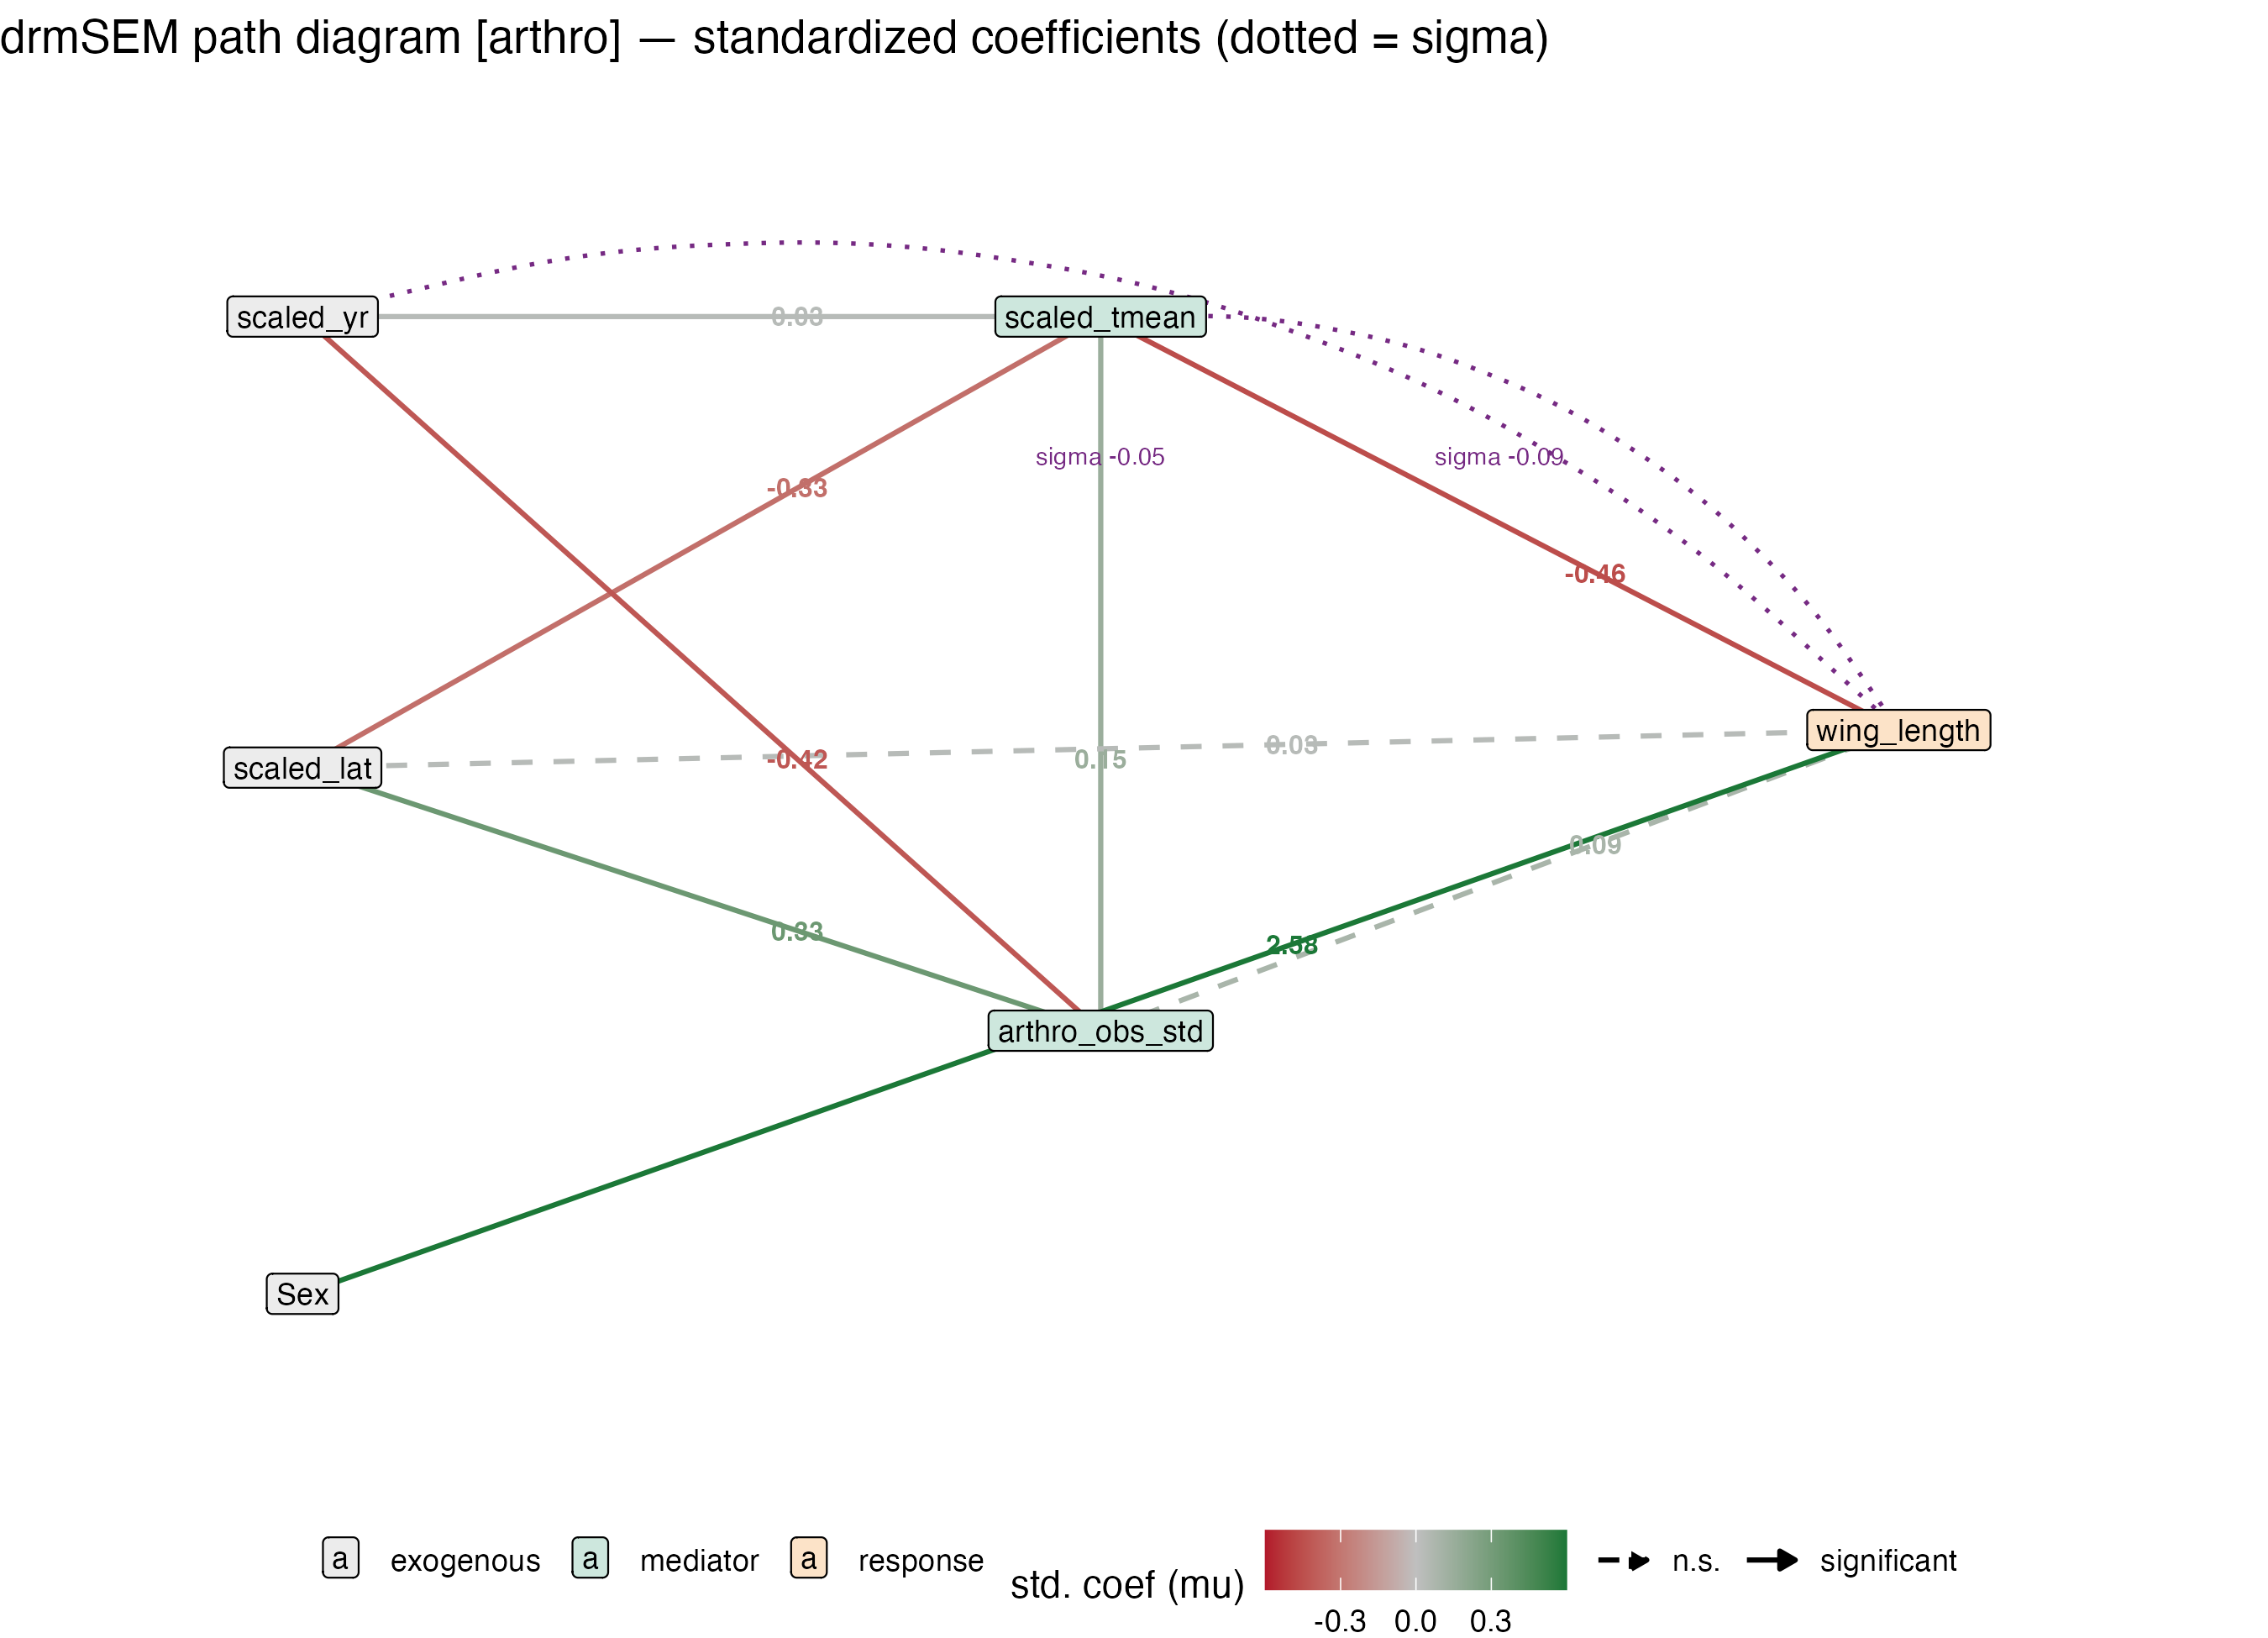
<figcaption>Figure 7: Distributional piecewise structural equation model (drmSEM) of the hypothesised causal graph, fitted on the years with arthropod coverage. Arrows are mean-model paths coloured by standardised coefficient (green positive, red negative; solid = P &lt; 0.05, dashed = not significant); dotted purple arcs are the distributional (σ) paths into wing length. Year drives a steep decline in arthropod abundance, but arthropod abundance does not predict wing length, whereas temperature is directly associated with smaller wings within this window. Node roles: grey = exogenous, green = mediator, orange = response.</figcaption>
</figure>

## 1.7 Inclusion threshold sensitivity

Our main analysis required species to have at least 30 records and a minimum sampling span of 5 years; individuals of unknown sex were excluded. To assess whether the year → wing-length result is an artefact of these choices, we refitted the model across a grid of 18 threshold combinations spanning three minimum-record thresholds (30, 40, and 50), three minimum-span thresholds (5, 8, and 10 years), and with or without the unknown-sex filter (Supplementary Fig. S1). The year effect remained negative and its 95% credible interval excluded zero in 9 of 9 combinations that retained the sex filter. Dropping the sex filter consistently widened credible intervals to overlap zero in 6 of 9 combinations, indicating that unknown-sex records add noise rather than biological signal and that the sex-filter exclusion is a quality-control step rather than an arbitrary restriction. Across all threshold combinations retaining the sex filter, the negative year effect on wing length was consistent in direction and magnitude, supporting the conclusion that the reported decline is not an artefact of specific inclusion criteria.

## 1.8 Synthesis

Our results present a coherent but nuanced picture. Wing length declined modestly and heterogeneously across 89 Atlantic Forest passerines over 28 years, bill width did not decline (increasing slightly instead), and among-individual variability in wing length rose — consistent with a population responding unevenly to a deteriorating environment rather than shifting uniformly toward a new optimum. Over the same region and period, arthropod prey abundance fell steeply, and this collapse was robust to how ants were treated and to the exclusion of open-habitat records.

The diet-interaction analysis, however, complicates a simple food-limitation interpretation. The temporal decline in wing length was not steeper in species most reliant on invertebrate prey; if anything it was weaker, with less insectivorous species declining more. This argues against a direct, diet-mediated pathway from arthropod scarcity to body-size loss, and the distributional causal model made the same point explicitly: arthropod abundance, though declining steeply, had no direct effect on wing length, while the rising among-individual variance was reproduced under the causal graph (<a href="#fig-drmsem" class="quarto-xref">Figure 7</a>). A more likely reconciliation is that both the arthropod decline and the morphological change are downstream consequences of the same regional warming, rather than standing in a direct cause-and-effect relationship: temperature shapes body size through thermoregulatory mechanisms consistent with Bergmann’s rule, while simultaneously suppressing arthropod populations through independent phenological and metabolic pathways ([Gardner et al. 2011](#ref-gardner_declining_2011); [Dirzo et al. 2014](#ref-dirzo2014defaunation)). Strictly insectivorous species may additionally buffer size loss through behavioural compensation — increased foraging effort or prey switching — in ways that facultative omnivores and frugivores cannot ([Robb et al. 2008](#ref-robb2008food)).

We caution that our design links birds and prey at the level of shared region and period rather than through a joint model of individual birds and their local food supply. A more powerful test would track arthropod abundance at the scale of individual capture localities and model it as a time-varying predictor of body size; we identify this as the priority next step. Even so, the co-occurrence of a regional prey collapse and morphological change in avian predators across three decades highlights an under-appreciated dimension of climate-change impacts on tropical biodiversity — one in which warming may simultaneously reshape the phenotypes of predators and diminish the resources that sustain them.

# 2. Methods

## 2.1 Morphological data and inclusion criteria

Bird morphological data were obtained from the ATLANTIC BIRD TRAITS dataset ([Rodrigues et al. 2019](#ref-rodrigues_atlantic_2019)), a compilation of measurements from the Atlantic forests of South America. We restricted records to the order Passeriformes; to individuals aged as adults at collection; to records dated 1990–2018; and to localities within a 20-km buffer of the Atlantic Forest domain. We retained only species with at least 30 records and a sampling span of at least 5 years, and excluded individuals of unknown sex. These criteria yielded 89 species. Species binomials were reconciled to the taxonomy of the phylogeny by recoding six names (e.g., *Ceratopipra rubrocapilla* → *Pipra rubrocapilla*; *Myiothlypis leucoblephara* → *Basileuterus leucoblepharus*).

Wing length was chosen as the body-size index because it had the least missing data among candidate traits. We coalesced right-wing, left-wing, and unspecified wing measurements (in that order of priority) into a single variable, assuming bilateral symmetry, to reduce missingness. Bill width was analysed as a complementary trait. Year and latitude were mean-centred and scaled to unit standard deviation prior to modelling; latitude was multiplied by −1 before scaling so that larger values denote more southerly (and typically cooler) localities. Diet categories were assigned from EltonTraits ([Wilman et al. 2014](#ref-wilman2014eltontraits)); the analytical species are overwhelmingly invertebrate-consuming, and only a small number have no invertebrate component in their diet.

## 2.2 Climate context

We did not estimate a temporal temperature or precipitation trend from the morphological dataset. The `Annual_mean_temperature` and `Annual_rainfall` fields in ATLANTIC BIRD TRAITS are static long-term climatologies attached to each locality rather than conditions measured at the time of capture: across the sampled localities, 97% carry a single temperature value regardless of how many years they were sampled, so any apparent change over time reflects which localities were visited when, not climatic change. We therefore treat warming over the study region and period as established by independent climatological records and the broader literature ([Gardner et al. 2011](#ref-gardner_declining_2011); [Teplitsky and Millien 2014](#ref-teplitsky_climate_2014)).

To move beyond year as a proxy for climate, we additionally link each record to **time-resolved** monthly temperature from WorldClim historical weather (CRU-TS 4.09 downscaled with WorldClim 2.1; Fick and Hijmans ([2017](#ref-fick2017worldclim)); Harris et al. ([2020](#ref-harris2020crudata))) at the record’s coordinates and year of capture (`climate_extraction.R`). This yields the actual temperature experienced by each individual, allowing body size to be modelled directly against climate.

## 2.3 Phylogeny

We obtained species-level trees from the complete and dynamic avian phylogeny of McTavish et al. ([2025](#ref-mctavish2025tree)), accessed through the `clootl` R package ([Miller et al. 2026](#ref-miller2026clootl)), which supersedes the earlier Jetz et al. ([2012](#ref-jetz2012global)) BirdTree (Hackett-backbone) trees used in initial analyses. We retrieved the trees through the `prepR4pcm` package ([Nakagawa, Ortega, et al. 2026](#ref-nakagawa2026prepr4pcm)) and used its four-stage matching cascade (exact, normalised, synonym, and fuzzy matching) to reconcile our species names to the phylogeny’s tip labels, auditing every match so that no species was silently dropped, before aligning the trait data to the pruned tree. We drew 50 trees from a pool of 100 to represent phylogenetic uncertainty. For models conditioned on a single topology, we constructed a phylogenetic covariance matrix by inverting the matrix returned by `MCMCglmm::inverseA` (scaled, tips only). To propagate phylogenetic uncertainty, we refitted the model across all 50 trees and pooled estimates across trees using Rubin’s rules ([Nakagawa and Villemereuil 2019](#ref-nakagawa2019rubin)), reporting Wald–Rubin 95% intervals, rather than naively concatenating posterior draws.

## 2.4 Body-size and bill-width models

We fitted Bayesian multilevel models in `brms` ([Bürkner 2017](#ref-burkner2017brms)) with Stan. For wing length: wing length ~ 1 + sex + scaled year + scaled latitude + (1 + scaled year \|\| species) + (1 \| binomial), where the `(1 | binomial)` term carried the phylogenetic covariance matrix, the double-bar species term estimated uncorrelated species intercepts and year slopes, sex was included as a fixed effect, and an analogous model for bill width omitted sex. Priors were weakly informative: Normal(71, 15) and Normal(9, 2.5) on the wing- and bill-width intercepts respectively, Normal(0, 10) on regression coefficients, and Half-Cauchy(0, 1) on standard-deviation and residual parameters. Models were run with multiple chains to convergence and assessed with the potential scale-reduction factor (R̂), effective sample sizes, posterior predictive checks, and trace plots. We summarise effects as posterior means with 95% credible intervals, and report the proportion of among-species variance attributable to phylogeny via a derived hypothesis on the variance components.

To handle missing morphological data we used multiple imputation by chained equations (`mice`) ([Buuren and Groothuis-Oudshoorn 2011](#ref-vanbuuren2011mice)), generating completed datasets and refitting the wing-length model across them with `brm_multiple`; we examined missingness patterns and intraclass correlations before imputation. To incorporate phylogenetic uncertainty, we refitted the wing-length model across the 50 sampled trees and pooled the estimates across trees with Rubin’s rules ([Nakagawa and Villemereuil 2019](#ref-nakagawa2019rubin)).

We use the coalesced wing-length variable as the single body-size response throughout, including in the phylogenetic-uncertainty analysis (`atlantic_parallel.R`).

## 2.5 Diet-interaction model

To test whether the temporal wing-length trend is modulated by dietary reliance on invertebrates, we extended the main wing-length model with an interaction term: scaled year × standardised invertebrate diet proportion (`diet_inv_std`), where `diet_inv_std` is the z-scored Diet-Inv variable from EltonTraits ([Wilman et al. 2014](#ref-wilman2014eltontraits)) (proportion of diet from invertebrates, 0–100 scale, computed across species with available data). The model otherwise retained the same fixed effects (sex, scaled latitude), random structure (uncorrelated species intercepts and year slopes), and phylogenetic covariance as the main analysis. We additionally fitted a parallel model substituting a binary diet category (Invertebrate vs. Other, collapsing FruiNect, Omnivore, and PlantSeed). Both models were run across 10 sampled trees and pooled with Rubin’s rules (`atlantic_diet_interaction.R`). 13 species lacking EltonTraits diet data were excluded from these models only.

## 2.6 Trait-variability meta-analysis

For each species we computed the log coefficient-of-variation ratio (lnCVR) of wing length and of bill width between the early (1990–2006) and late (2013–2018) quartiles of the record, with its sampling variance following Nakagawa et al. ([2015](#ref-nakagawa2015metaanalysis)), using the among-species correlation between log mean and log standard deviation within each period. We combined effect sizes in random-effects models (REML) using `metafor` ([Viechtbauer 2010](#ref-viechtbauer2010metafor)), reporting the meta-analytic mean, its 95% confidence interval, heterogeneity (I²), and the test for heterogeneity.

## 2.7 Arthropod abundance

We obtained invertebrate abundance records from the PREDICTS database ([<span class="nocase">Hudson et al.</span> 2017](#ref-hudson2017database)), accessed through the `predictsr` package ([Duffin 2025](#ref-duffin2025predictsr)), retaining Arthropoda of the classes Insecta and Arachnida with abundance-type diversity metrics in South America, and restricting to forested biomes (tropical and subtropical moist and dry broadleaf forests, temperate broadleaf and mixed forests, and mangroves) to exclude open-habitat assemblages unlikely to be available to Atlantic Forest passerines. Ants (Formicidae) were retained in the main model because, although most passerines rarely consume ant workers, several species opportunistically take flying reproductives (alates) during nuptial flights ([Helms et al. 2016](#ref-helms_are_2016)). We modelled raw counts with negative-binomial regression in `brms`, including the natural log of sampling effort as an offset and scaled year as the predictor, with weakly informative priors (Normal(0, 10) on the intercept, Normal(0, 1) on the year coefficient, and the default Gamma(0.01, 0.01) on the shape parameter). As a conservative sensitivity check we repeated the analysis excluding Formicidae entirely; the ant-exclusion model returned a shallower decline, confirming that the main result is not driven by ant abundance trends. Coefficients are reported on the standardized-year scale and as exponentiated multiplicative effects.

## 2.8 Distributional causal model

To complement the regression models with an explicit causal test, we fitted a distributional piecewise structural equation model (drmSEM): a piecewise SEM ([Shipley 2009](#ref-shipley2009confirmatory); [Lefcheck 2016](#ref-lefcheck2016piecewisesem)) in which every node is a distributional regression (mean and variance submodels) fitted with `drmTMB`, and overall fit is assessed by Shipley’s test of directed separation (Fisher’s C) ([Nakagawa, Pottier, et al. 2026](#ref-nakagawa2026drmsem)). The graph specified temperature as a function of year and latitude; arthropod abundance as a function of year, temperature and latitude; and wing length as a function of temperature, arthropod abundance, sex and latitude, with a variance submodel letting the residual standard deviation of wing length depend on year and temperature. Species entered as i.i.d. random intercepts, and year → wing effects were decomposed into direct, mean-mediated and distribution-mediated components by simulation.

Temperature was the time-resolved WorldClim value at each record’s coordinates and year of capture (`climate_extraction.R`). The arthropod node used the observed log abundance per unit sampling effort from the PREDICTS records, aggregated to an inverse-distance-weighted locality × year index (200-km search radius) and standardised; because this index is ultimately a year- and locality-level aggregate broadcast to individual birds, its standard errors are anticonservative and its coefficients should be read as approximate. The latitude → arthropod edge is a statistical adjustment for the sampling structure of that aggregate, not a causal claim.

We fitted the graph at two scopes. Requiring arthropod coverage restricts the data to 1998–2008 (2,149 records, 82 species); this is the model with the arthropod node. To check the variance result on the complete record we also fitted a temperature-only variant (no arthropod node) on all 9,180 records (1990–2018, 86 species). We additionally refitted the graph with the wing-length node’s species intercept replaced by a phylogenetic random effect (Pagel’s λ selected per tree by AIC, pooled across 50 trees with Rubin’s rules); path directions were unchanged. The drmSEM is a complementary, observational causal analysis; the Bayesian phylogenetic models above remain the primary, authoritative inference. Code is in `atlantic_drmsem.R`.

## 2.9 Data and code availability

The ATLANTIC BIRD TRAITS dataset ([Rodrigues et al. 2019](#ref-rodrigues_atlantic_2019)), the EltonTraits database ([Wilman et al. 2014](#ref-wilman2014eltontraits)), the BirdTree phylogeny ([Jetz et al. 2012](#ref-jetz2012global)), and the PREDICTS database ([<span class="nocase">Hudson et al.</span> 2017](#ref-hudson2017database)) are publicly available from their original sources. Analysis code (`Analysis/atlantic_birds_ms.Rmd`) and fitted model objects are provided in the project repository.

## References

Ashton, Kyle G. 2002. “Patterns of Within-Species Body Size Variation of Birds: Strong Evidence for Bergmann’s Rule.” *Global Ecology and Biogeography* 11 (6): 505–23. <https://doi.org/10.1046/j.1466-822X.2002.00313.x>.

Bergmann, Carl. 1847. “Über Die Verhältnisse Der Warmeokonomiedie Thiere Zu Ihrer Grösse.” *Göttinger Studien* 3: 359–708. <https://www.digitale-sammlungen.de/en/view/bsb10306637?page=1>.

Bürkner, Paul-Christian. 2017. “Brms: An R Package for Bayesian Multilevel Models Using Stan.” *Journal of Statistical Software* 80 (1): 1–28. <https://doi.org/10.18637/jss.v080.i01>.

Buuren, Stef van, and Karin Groothuis-Oudshoorn. 2011. “<span class="nocase">mice</span>: Multivariate Imputation by Chained Equations in R.” *Journal of Statistical Software* 45 (3): 1–67. <https://doi.org/10.18637/jss.v045.i03>.

Dirzo, Rodolfo, Hillary S. Young, Mauro Galetti, Gerardo Ceballos, Nick J. B. Isaac, and Ben Collen. 2014. “Defaunation in the Anthropocene.” *Science* 345 (6195): 401–6. <https://doi.org/10.1126/science.1251817>.

Duffin, Connor. 2025. *Predictsr: Access the ’PREDICTS’ Biodiversity Database*. <https://github.com/Biodiversity-Futures-Lab/predictsr>.

Fick, Stephen E., and Robert J. Hijmans. 2017. “WorldClim 2: New 1-Km Spatial Resolution Climate Surfaces for Global Land Areas.” *International Journal of Climatology* 37 (12): 4302–15. <https://doi.org/10.1002/joc.5086>.

Gardner, Janet L., Anne Peters, Michael R. Kearney, Leo Joseph, and Robert Heinsohn. 2011. “Declining Body Size: A Third Universal Response to Warming?” *Trends in Ecology & Evolution* 26 (6): 285–91. <https://doi.org/10.1016/j.tree.2011.03.005>.

Harris, Ian, Timothy J. Osborn, Phil Jones, and David Lister. 2020. “Version 4 of the CRU TS Monthly High-Resolution Gridded Multivariate Climate Dataset.” *Scientific Data* 7 (1): 109. <https://doi.org/10.1038/s41597-020-0453-3>.

Helms, Jackson A., Aaron P. Godfrey, Tayna Ames, and Eli S. Bridge. 2016. “Are Invasive Fire Ants Kept in Check by Native Aerial Insectivores?” *Biology Letters* 12 (5): 20160059. <https://doi.org/10.1098/rsbl.2016.0059>.

<span class="nocase">Hudson, Lawrence N, Tim Newbold, Sara Contu, et al.</span> 2017. “The Database of the Predicts (Projecting Responses of Ecological Diversity in Changing Terrestrial Systems) Project.” *Ecology and Evolution* 7 (1): 145–88.

Jetz, W, GH Thomas, JB Joy, K Hartmann, and AO Mooers. 2012. “The Global Diversity of Birds in Space and Time.” *Nature* 491 (7424): 444.

Lefcheck, Jonathan S. 2016. “<span class="nocase">piecewiseSEM</span>: Piecewise Structural Equation Modelling in R for Ecology, Evolution, and Systematics.” *Methods in Ecology and Evolution* 7 (5): 573–79. <https://doi.org/10.1111/2041-210X.12512>.

Mayr, Ernst. 1956. “Geographical Character Gradients and Climatic Adaptation.” *Evolution* 10 (1): 105–8. <https://doi.org/10.2307/2406103>.

McTavish, Emily Jane, Jeff A. Gerbracht, Mark T. Holder, et al. 2025. “A Complete and Dynamic Tree of Birds.” *Proceedings of the National Academy of Sciences* 122 (18): e2409658122. <https://doi.org/10.1073/pnas.2409658122>.

Miller, Eliot T., Luna L. Sánchez Reyes, and Emily Jane McTavish. 2026. “Clootl: An R Package for Accessing and Manipulating a Complete, Versioned Avian Phylogeny.” *bioRxiv*, 2026.04.23.720449. <https://doi.org/10.64898/2026.04.23.720449>.

Nakagawa, Shinichi, Santiago Ortega, Ayumi Mizuno, et al. 2026. *prepR4pcm: Prepare Data and Trees for Phylogenetic Comparative Methods*. <https://github.com/itchyshin/prepR4pcm>.

Nakagawa, Shinichi, Patrice Pottier, Ayumi Mizuno, Eduardo S. A. Santos, and Malgorzata Lagisz. 2026. *drmSEM: Distributional Piecewise Structural Equation Models (Built on drmTMB)*. <https://github.com/itchyshin/drmSEM>.

Nakagawa, Shinichi, Robert Poulin, Kerrie Mengersen, et al. 2015. “Meta-Analysis of Variation: Ecological and Evolutionary Applications and Beyond.” *Methods in Ecology and Evolution* 6 (2): 143–52. <https://doi.org/10.1111/2041-210X.12309>.

Nakagawa, Shinichi, and Pierre de Villemereuil. 2019. “A General Method for Simultaneously Accounting for Phylogenetic and Species Sampling Uncertainty via Rubin’s Rules in Comparative Analysis.” *Systematic Biology* 68 (4): 632–41. <https://doi.org/10.1093/sysbio/syy089>.

Ozgul, Arpat, Shripad Tuljapurkar, Tim G. Benton, Josephine M. Pemberton, Tim H. Clutton-Brock, and Tim Coulson. 2009. “The Dynamics of Phenotypic Change and the Shrinking Sheep of St. Kilda.” *Science* 325 (5939): 464–67. <https://doi.org/10/db5kwc>.

Parmesan, Camille, and Gary Yohe. 2003. “A Globally Coherent Fingerprint of Climate Change Impacts Across Natural Systems.” *Nature* 421 (6918): 37. <https://doi.org/10.1038/nature01286>.

Robb, Gillian N., Roisin A. McDonald, Dan E. Chamberlain, and Stuart Bearhop. 2008. “Food for Thought: Supplementary Feeding as a Driver of Ecological Change in Avian Populations.” *Frontiers in Ecology and the Environment* 6 (9): 476–84. <https://doi.org/10.1890/060152>.

Rodrigues, Rodolpho Credo, Érica Hasui, Julia Camara Assis, et al. 2019. “ATLANTIC BIRD TRAITS: A Data Set of Bird Morphological Traits from the Atlantic Forests of South America.” *Ecology* 100 (6): e02647. <https://doi.org/10.1002/ecy.2647>.

Ryding, Sara, Alexandra McQueen, Marcel Klaassen, Glenn J. Tattersall, and Matthew R. E. Symonds. 2024. “Long- and Short-Term Responses to Climate Change in Body and Appendage Size of Diverse Australian Birds.” *Global Change Biology* 30 (10): e17517. <https://doi.org/10.1111/gcb.17517>.

Schmidt, Niels, and Per Jensen. 2005. “Concomitant Patterns in Avian and Mammalian Body Length Changes in Denmark.” *Ecology and Society* 10 (2). <https://doi.org/10/gf389w>.

Sheridan, Jennifer A., and David Bickford. 2011. “Shrinking Body Size as an Ecological Response to Climate Change.” *Nature Climate Change* 1 (8): 401–6. <https://doi.org/10.1038/nclimate1259>.

Shipley, Bill. 2009. “Confirmatory Path Analysis in a Generalized Multilevel Context.” *Ecology* 90 (2): 363–68. <https://doi.org/10.1890/08-1034.1>.

Teplitsky, Celine, and Virginie Millien. 2014. “Climate Warming and Bergmann’s Rule Through Time: Is There Any Evidence?” *Evolutionary Applications* 7 (1): 156–68. <https://doi.org/10.1111/eva.12129>.

Teplitsky, Céline, James A. Mills, Jussi S. Alho, John W. Yarrall, and Juha Merilä. 2008. “Bergmann’s Rule and Climate Change Revisited: Disentangling Environmental and Genetic Responses in a Wild Bird Population.” *Proceedings of the National Academy of Sciences* 105 (36): 13492–96. <https://doi.org/10.1073/pnas.0800999105>.

Viechtbauer, Wolfgang. 2010. “Conducting Meta-Analyses in R with the <span class="nocase">metafor</span> Package.” *Journal of Statistical Software* 36 (3): 1–48. <https://doi.org/10.18637/jss.v036.i03>.

Weeks, Brian C., David E. Willard, Marketa Zimova, et al. 2020. “Shared morphological consequences of global warming in North American migratory birds.” *Ecology Letters* 23 (2): 316–25. <https://doi.org/10.1111/ele.13434>.

Wilman, Hamish, Jonathan Belmaker, Jennifer Simpson, Carolina de la Rosa, Marcelo M Rivadeneira, and Walter Jetz. 2014. “EltonTraits 1.0: Species-Level Foraging Attributes of the World’s Birds and Mammals: Ecological Archives E095-178.” *Ecology* 95 (7): 2027–27.